<a href="https://colab.research.google.com/github/Handinoasa/MachineLearning_2026/blob/main/Week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Praktikum 1

In [ ]:
# Persiapan data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# Seleksi Fitur

X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

display(y.head())

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


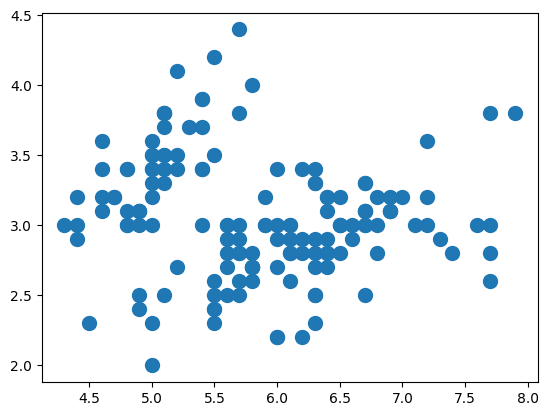

In [ ]:
# Plot Data
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

In [ ]:
# Buat Model KMeans
# Kali ini kita coba menggunakan k=2 - anggap saja kita tidak tahu jumlah label ada 3 :)

from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

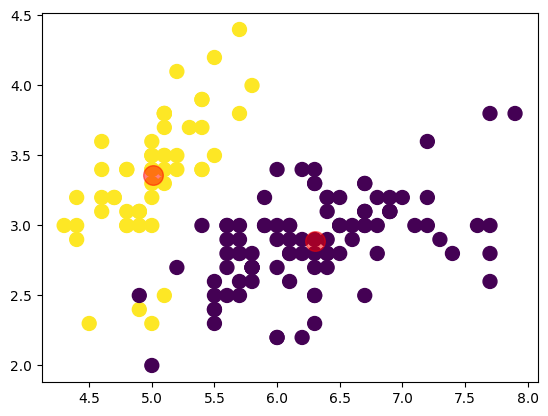

In [ ]:
# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

In [ ]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


In [10]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


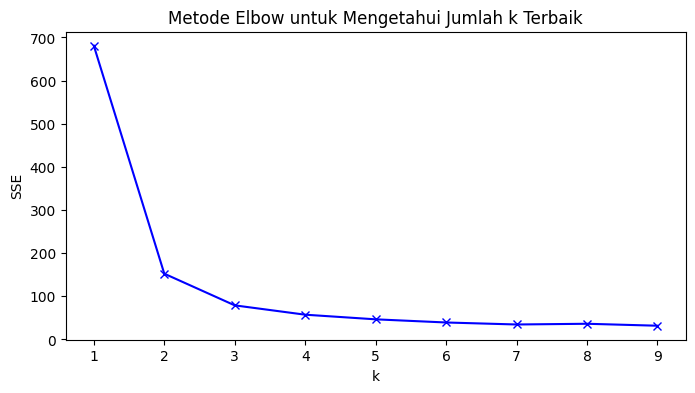

In [12]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [13]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94084142614601
k=4; SSE=57.317873214285726
k=5; SSE=46.56163015873017
k=6; SSE=39.251830892636775
k=7; SSE=34.607365934065925
k=8; SSE=36.278577489177486
k=9; SSE=31.748072640594696


#Praktikum 2


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

###Pengantar K-Means

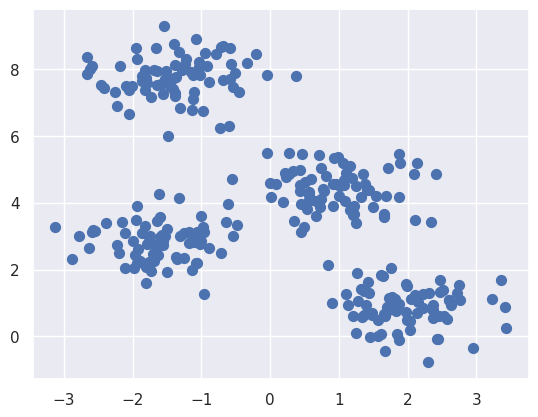

In [15]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [16]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

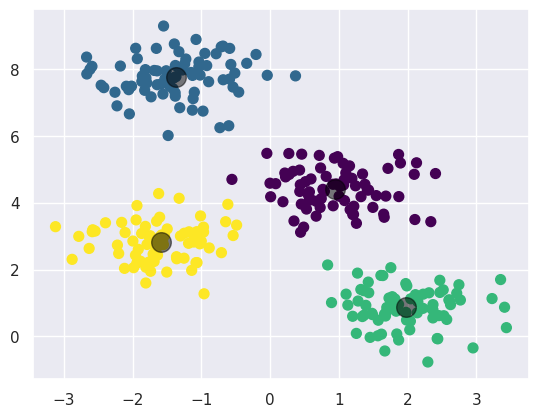

In [17]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

###Algoritma Expectation-Maximization

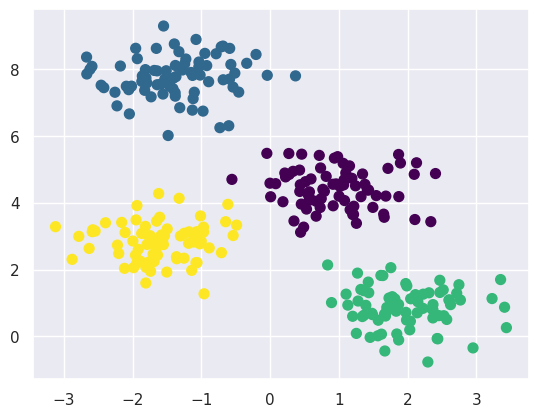

In [18]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)

        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

###Perubahan random

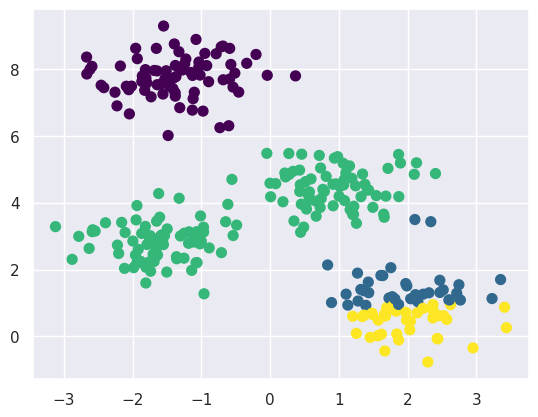

In [19]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

###Optimalisasi Jumlah Klaster

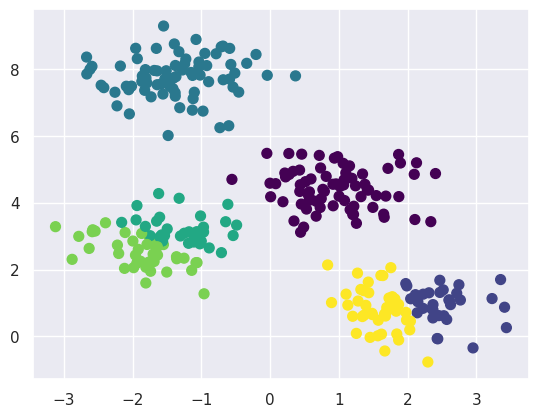

In [20]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

###Batas Klaster yang Tidak Selalu Linier

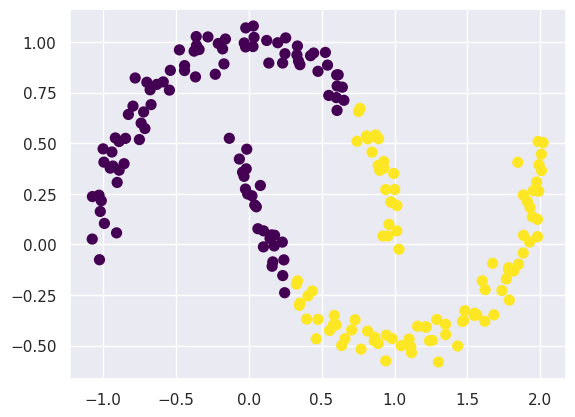

In [22]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


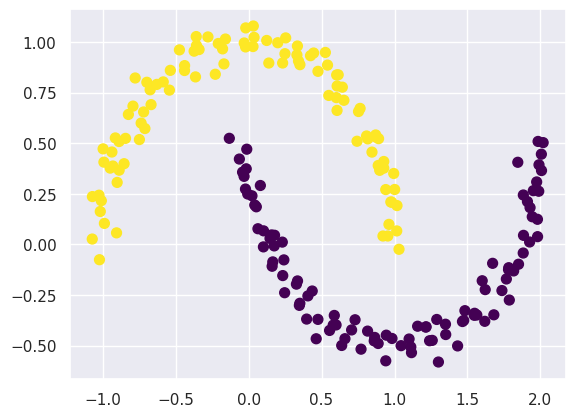

In [23]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

###Contoh Kasus 1: Karakter Angka

In [24]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [25]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

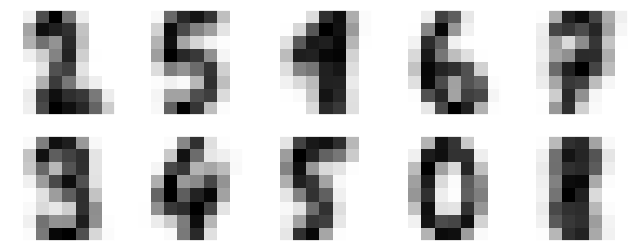

In [26]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [28]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

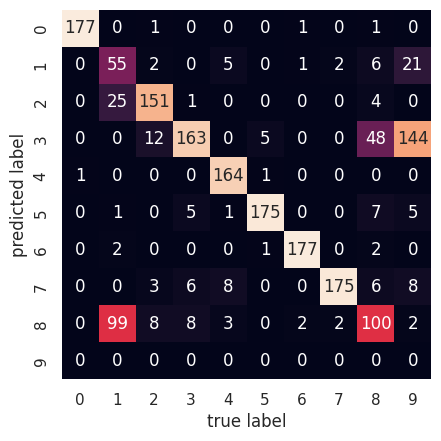

In [29]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [30]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

0.9410127991096272

###Studi Kasus 2: Kompresi Citra

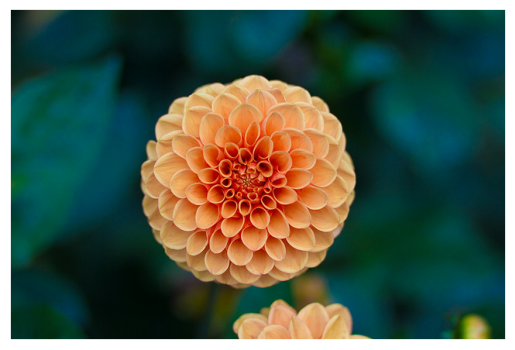

In [31]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [32]:
flower.shape

(427, 640, 3)

In [33]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

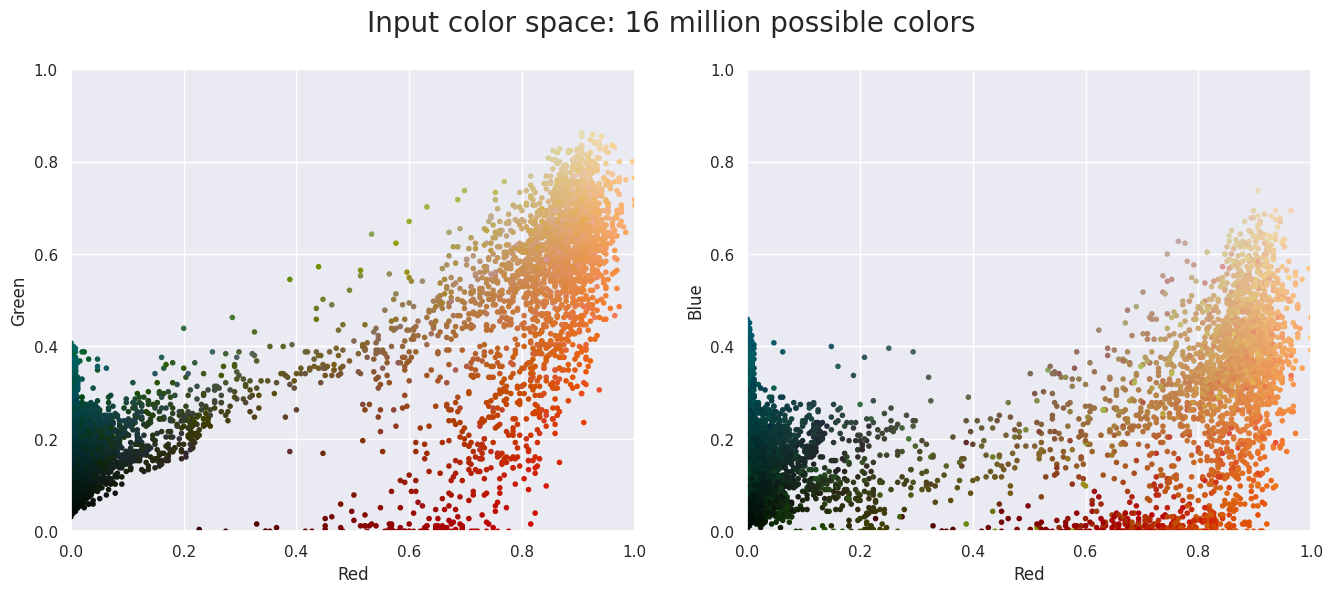

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # Memilih subset acak agar plotting lebih cepat
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20)

plot_pixels(data, title='Input color space: 16 million possible colors')

plt.show()

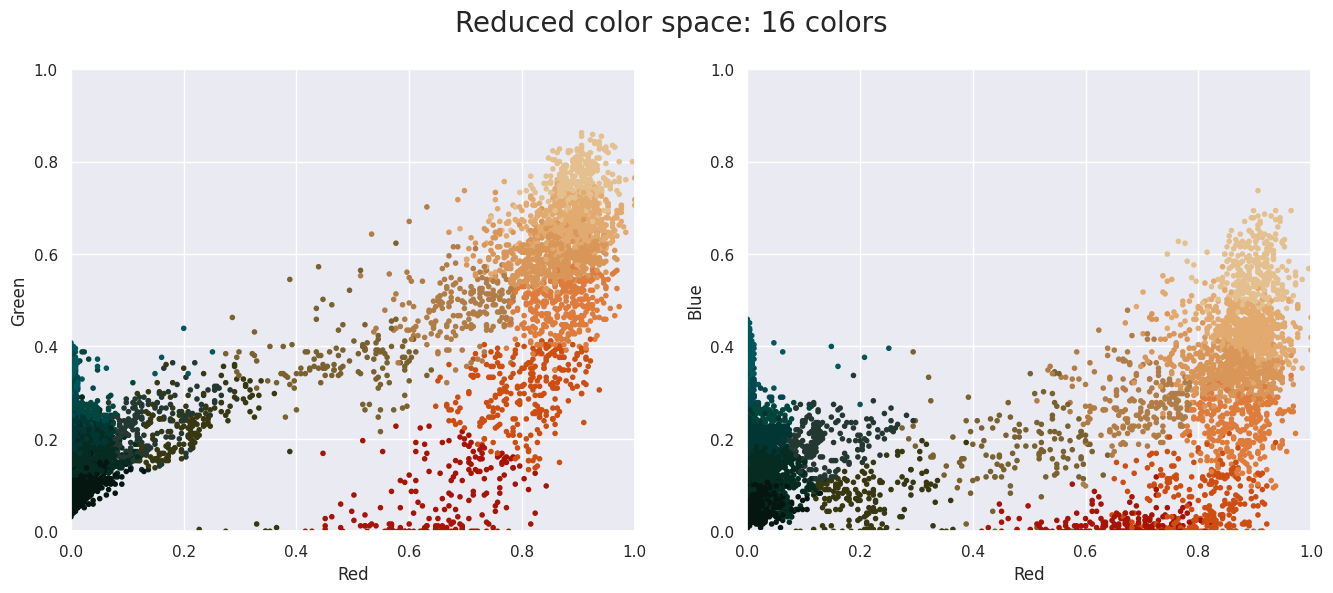

In [41]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

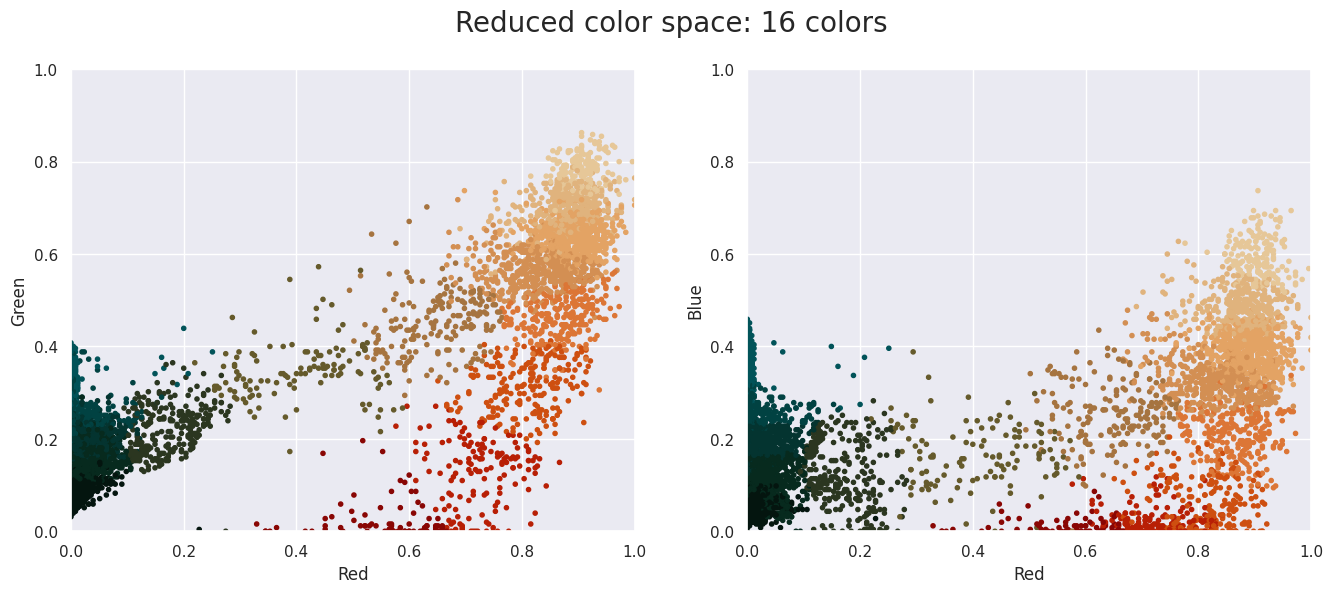

In [42]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

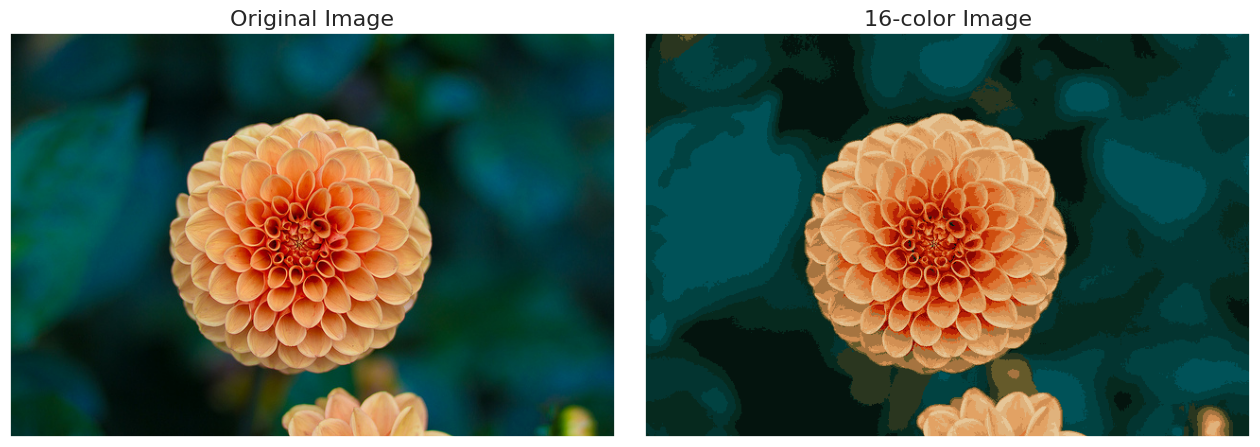

In [43]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

#Praktikum 3

###Pembuatan Dataset Sintetis
Untuk mempelajari DBSCAN, kita akan membuat dataset sederhana berupa 3 klaster buatan menggunakan fungsi  make_blobs  dari Scikit-Learn.

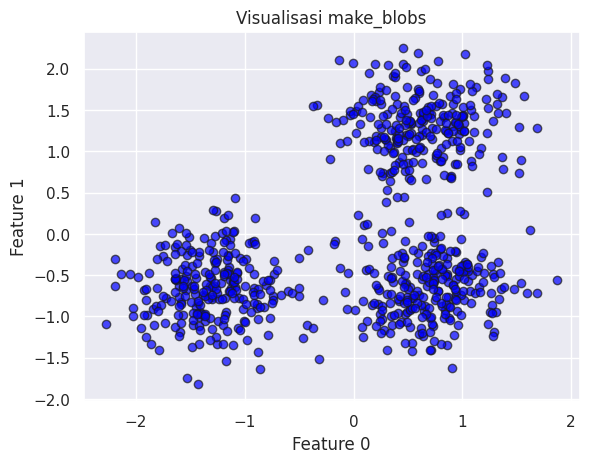

In [48]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

# Standardisasi fitur dengan menghilangkan mean dan menskalakan ke variansi unit
X = StandardScaler().fit_transform(X)

# Menggambar scatter plot dari kolom 0 (sumbu X) dan kolom 1 (sumbu Y)
plt.scatter(X[:, 0], X[:, 1], c='blue', marker='o', edgecolor='k', alpha=0.7)

# Menambahkan judul dan label sumbu agar lebih rapi
plt.title("Visualisasi make_blobs")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

# Memunculkan jendela plot ke layar
plt.show()

###Compute DBSCAN

Sekarang kita terapkan DBSCAN pada data tersebut.

Label yang ditetapkan oleh DBSCAN dapat diakses melalui atribut labels_. Titik data yang dianggap noise akan diberi label khusus.

In [52]:
import numpy as np
from sklearn import metrics


from sklearn.cluster import DBSCAN


# 2. Tambahkan 'DBSCAN' saat inisialisasi model
db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Menghitung jumlah klaster, mengabaikan noise (label -1)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18



- eps=0.3 → jarak maksimum antar titik untuk dianggap tetangga.

- min_samples=10 → jumlah minimum titik dalam radius eps agar dianggap area padat (core sample).

- Label hasil klasterisasi tersedia di labels. Nilai -1 berarti titik tersebut dianggap noise atau outlier.

Estimated number of clusters: 3
Estimated number of noise points: 18
Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


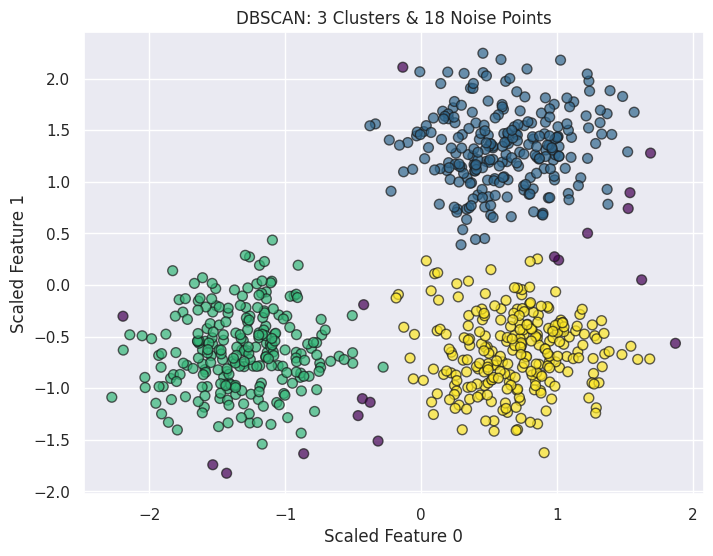

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler


centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

# Standardisasi fitur sangat disarankan untuk DBSCAN
X = StandardScaler().fit_transform(X)


db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_


# Menghitung jumlah klaster (mengabaikan noise/label -1)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

# Menampilkan hasil evaluasi klaster dengan 3 angka di belakang koma
print("Homogeneity: %0.3f" % metrics.homogeneity_score(labels_true, labels))
print("Completeness: %0.3f" % metrics.completeness_score(labels_true, labels))
print("V-measure: %0.3f" % metrics.v_measure_score(labels_true, labels))
print("Adjusted Rand Index: %0.3f" % metrics.adjusted_rand_score(labels_true, labels))
print("Adjusted Mutual Information: %0.3f" % metrics.adjusted_mutual_info_score(labels_true, labels))
print("Silhouette Coefficient: %0.3f" % metrics.silhouette_score(X, labels))


plt.figure(figsize=(8, 6))

# Membuat scatter plot, warna titik ditentukan oleh label klaster dari DBSCAN
# Titik noise (-1) akan mendapatkan warna ujung dari colormap (biasanya ungu/kuning tergantung cmap)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, edgecolor='k', alpha=0.7)

plt.title(f"DBSCAN: {n_clusters_} Clusters & {n_noise_} Noise Points")
plt.xlabel("Scaled Feature 0")
plt.ylabel("Scaled Feature 1")

# Menampilkan plot ke layar
plt.show()


- Homogeneity → apakah tiap klaster hanya berisi satu label asli.

- Completeness → apakah semua sampel dengan label asli yang sama masuk ke klaster yang sama.

- V-measure → rata-rata harmonik dari homogeneity dan completeness.

- Adjusted Rand Index (ARI) → kesesuaian antara klasterisasi dengan label asli.

- Adjusted Mutual Information (AMI) → kesamaan informasi antara klasterisasi dengan label asli.

- Silhouette Coefficient → seberapa baik data dikelompokkan (nilai mendekati 1 berarti bagus, mendekati 0 berarti berada di batas, negatif berarti salah klaster).

### Visualisasi Hasil Klasterisasi
Kita akan memvisualisasikan hasil DBSCAN.

- Core sample ditampilkan dengan titik besar.

- Non-core sample ditampilkan dengan titik kecil.

- Noise ditampilkan dengan warna hitam.

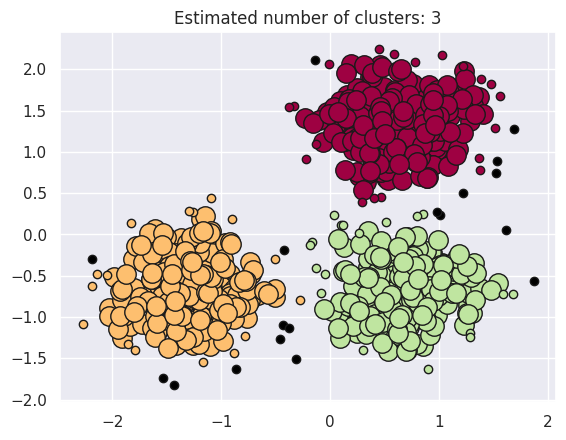

In [59]:
import numpy as np
import matplotlib.pyplot as plt

unique_labels = set(labels)

# 1. Menggunakan np.zeros_like untuk menginisialisasi mask bernilai False
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

# 2. Menggunakan np.linspace untuk mendistribusikan spektrum warna
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Warna hitam secara spesifik digunakan untuk noise (label -1).
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    # 3. Plot titik inti (core samples) dengan ukuran marker yang besar (14)
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    # 4. Plot titik tepi (border samples) dengan ukuran marker yang lebih kecil (6)
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

# 5. Menambahkan fungsi penamaan judul dan penampil gambar
plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

Interpretasi visual:

- Titik besar berwarna → core samples dalam klaster.

- Titik kecil berwarna → non-core samples, tetap termasuk klaster.

- Titik hitam → noise/outlier.

#Tugas Praktikum


###1. Tugas K-Means

Buatlah sebuah model K-Means dengan ketentuan,

1. Gunakan data 'Mall_Customers.csv'

2. Tentukan fitur apa yang tepat untuk melakukan clustering (minimal 2)

3. Buatlah model K-Means dengan mempertimbangkan jumlah
k
k yang terbaik.

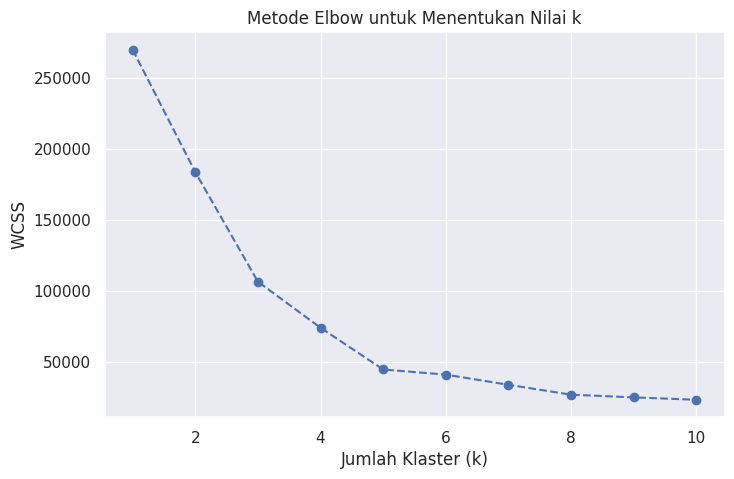

K-Means clustering selesai dieksekusi dengan k=5.


In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Load Data (Pastikan file CSV berada di folder yang sama dengan script)
df = pd.read_csv('Mall_Customers.csv')

# 2. Pemilihan Fitur: Mengambil kolom 'Annual Income (k$)' dan 'Spending Score (1-100)'
# Biasanya berada di indeks kolom ke-3 dan ke-4
X_kmeans = df.iloc[:, [3, 4]].values

# 3. Menentukan k terbaik menggunakan Metode Elbow (WCSS / Inertia)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_kmeans)
    wcss.append(kmeans.inertia_)

# Menampilkan grafik Elbow
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Metode Elbow untuk Menentukan Nilai k')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('WCSS')
plt.show()

# Observasi: Pada grafik biasanya akan terlihat "siku" (patahan tajam) di k = 5.
# Kita gunakan k=5 untuk model akhir K-Means.
kmeans_final = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans_final.fit_predict(X_kmeans)

print("K-Means clustering selesai dieksekusi dengan k=5.")

###2. Tugas DBSCAN
1. Buat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi.

2. Jalankan DBSCAN dengan eps=0.2, min_samples=5, hitung jumlah klaster & noise.

3. Evaluasi dengan metrik: Homogeneity, Completeness, V-measure, ARI, AMI, Silhouette.

4. Visualisasikan hasil DBSCAN (core sample = titik besar, non-core = titik kecil, noise = hitam).

5. Lakukan eksperimen:

  - eps = 0.05, 0.1, 0.3, 0.5

  - min_samples = 3, 10, 20

  - Catat perubahan klaster, noise, dan kualitas evaluasi.

=== HASIL MODEL DASAR (eps=0.2, min_samples=5) ===
Jumlah klaster : 2
Jumlah noise   : 0
Homogeneity    : 1.000
Completeness   : 1.000
V-measure      : 1.000
ARI            : 1.000
AMI            : 1.000
Silhouette     : 0.391


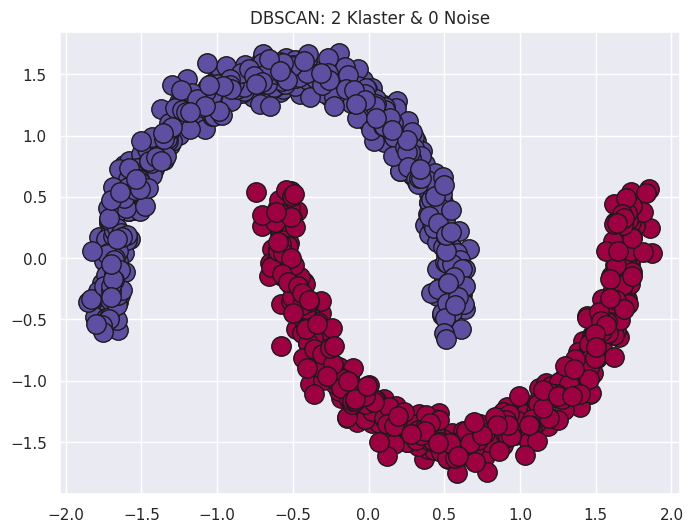


=== HASIL EKSPERIMEN PARAMETER DBSCAN ===
eps=0.05 | min_samples=3  | Klaster: 69  | Noise: 186  | Silhouette: 0.113
eps=0.05 | min_samples=10 | Klaster: 3   | Noise: 970  | Silhouette: -0.294
eps=0.05 | min_samples=20 | Klaster: 0   | Noise: 1000 | Silhouette: nan
eps=0.1  | min_samples=3  | Klaster: 2   | Noise: 14   | Silhouette: 0.252
eps=0.1  | min_samples=10 | Klaster: 7   | Noise: 57   | Silhouette: 0.162
eps=0.1  | min_samples=20 | Klaster: 6   | Noise: 850  | Silhouette: -0.360
eps=0.3  | min_samples=3  | Klaster: 2   | Noise: 0    | Silhouette: 0.391
eps=0.3  | min_samples=10 | Klaster: 2   | Noise: 0    | Silhouette: 0.391
eps=0.3  | min_samples=20 | Klaster: 2   | Noise: 0    | Silhouette: 0.391
eps=0.5  | min_samples=3  | Klaster: 2   | Noise: 0    | Silhouette: 0.391
eps=0.5  | min_samples=10 | Klaster: 2   | Noise: 0    | Silhouette: 0.391
eps=0.5  | min_samples=20 | Klaster: 2   | Noise: 0    | Silhouette: 0.391


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# 1. Buat dataset make_moons dan normalisasi
X, labels_true = make_moons(n_samples=1000, noise=0.05, random_state=42)
X = StandardScaler().fit_transform(X)

# 2. Jalankan DBSCAN model dasar
db = DBSCAN(eps=0.2, min_samples=5).fit(X)
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

# 3. Evaluasi Model Dasar
print("=== HASIL MODEL DASAR (eps=0.2, min_samples=5) ===")
print(f"Jumlah klaster : {n_clusters_}")
print(f"Jumlah noise   : {n_noise_}")
print("Homogeneity    : %0.3f" % metrics.homogeneity_score(labels_true, labels))
print("Completeness   : %0.3f" % metrics.completeness_score(labels_true, labels))
print("V-measure      : %0.3f" % metrics.v_measure_score(labels_true, labels))
print("ARI            : %0.3f" % metrics.adjusted_rand_score(labels_true, labels))
print("AMI            : %0.3f" % metrics.adjusted_mutual_info_score(labels_true, labels))
print("Silhouette     : %0.3f" % metrics.silhouette_score(X, labels))

# 4. Visualisasi Model Dasar
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
plt.figure(figsize=(8, 6))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1] # Hitam untuk noise

    class_member_mask = labels == k

    # Core sample: titik besar
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col), markeredgecolor="k", markersize=14)

    # Non-core sample: titik kecil
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col), markeredgecolor="k", markersize=6)

plt.title(f"DBSCAN: {n_clusters_} Klaster & {n_noise_} Noise")
plt.show()

# 5. Eksperimen Parameter
print("\n=== HASIL EKSPERIMEN PARAMETER DBSCAN ===")
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

for e in eps_values:
    for m in min_samples_values:
        db_exp = DBSCAN(eps=e, min_samples=m).fit(X)
        lbls = db_exp.labels_

        n_c = len(set(lbls)) - (1 if -1 in lbls else 0)
        n_n = list(lbls).count(-1)

        # Silhouette score membutuhkan minimal 2 klaster, jika tidak akan error
        if n_c > 1:
            sil = metrics.silhouette_score(X, lbls)
        else:
            sil = float('nan') # Tidak valid jika hanya 1 klaster atau semuanya noise

        print(f"eps={e:<4} | min_samples={m:<2} | Klaster: {n_c:<3} | Noise: {n_n:<4} | Silhouette: {sil:.3f}")